### Middleware

Middleware provides a way to more tightly control the what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prommpts, tools selection, and output formatting.
- Applying rate limits, guadrails, and Pll detection.
- Adding ratries, fallbacks, and early termination logic.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

### Summarization MiddleWare
Automatically summarize conversation history wehen approaching token limits, preserving recent messages while comparison older context. Summarization is a useful for following ; only:

- Long- running conversations that exceed context windows.
- Multi-turn dialogs with extensive history.
- Applications where preserving full conversation context matter.

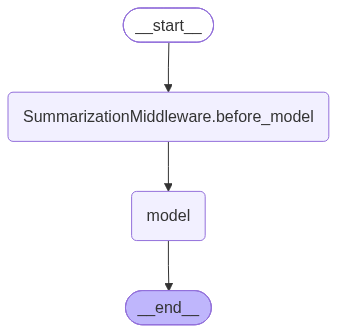

In [3]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# Agent with messagebased summerazation

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-120b",
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent

In [4]:
# thread_id
config = {"configurable":{"thread_id":"test1"}}

In [5]:
# Alternative test data
questions = [
    "What is 2+2",
    "what is 10*5",
    "what is 100/4",
    "what is 15-7",
    "what is 3*3",
    "what is 4*8",
]

for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]}, config=config)
    print(f"Messages:{response}")
    print(f"Messages:{len(response['messages'])}")

Messages:{'messages': [HumanMessage(content='What is 2+2', additional_kwargs={}, response_metadata={}, id='cb379542-8eee-462b-bdc4-826719c785aa'), AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'The user asks a simple math question: "What is 2+2". Answer: 4.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 77, 'total_tokens': 118, 'completion_time': 0.085427579, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.003837295, 'prompt_tokens_details': None, 'queue_time': 0.378293733, 'total_time': 0.089264874}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff567-b3d2-7ce1-805e-0684974565a1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 41, 'total_tokens': 118, 'output_token_details': {'reasoning': 22}})]}


### Token Size

In [72]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotel(city:str)->str:
    "Search hotels - returns long response to use more tokens."
    return f""" Hotels in {city}
1. Grand Hotel - 5 star, 3500/night, spa, pool, gym
2. City Inn - 4 star, 1800/night, business center
3. Budget Stay - 3 star, 750/night, free wifi
"""

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools = [search_hotel],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-120b",
            trigger=("tokens", 550),
            keep= ("tokens" , 200),
        )
    ]
)

config = {"configurable":{"thread_id":"test1"}}

# Token Counter(approx)
def count_tokens(messages):
    total_char = sum(len(str(m.content)) for m in messages)
    return total_char // 4 # 4 chars = 1 token

In [73]:
cities = ["Delhi", "Gurugram", "Noida", "Mumbai", "Banglore"]

for city in cities:
    response = agent.invoke(
        {"messages":[HumanMessage(content=f"Find hotels in the {city}")]},
        config=config
        )
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Delhi: ~271 tokens, 4 messages
[HumanMessage(content='Find hotels in the Delhi', additional_kwargs={}, response_metadata={}, id='34c3e108-02bb-434c-9daa-caef45a65147'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to find hotels in Delhi. Use the search_hotel function with city "Delhi".', 'tool_calls': [{'id': 'fc_09d5f1b9-1384-4566-b031-7b749b6d902b', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'search_hotel'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 130, 'total_tokens': 179, 'completion_time': 0.109338356, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.005352162, 'prompt_tokens_details': None, 'queue_time': 0.046318413, 'total_time': 0.114690518}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bc9a6c9b5f', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff63d-dba9-7112-b7

### Fraction

In [74]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotel(city:str)->str:
    "Search hotels - returns long response to use more tokens."
    return f""" Hotels in {city}
1. Grand Hotel - 5 star, 3500/night, spa, pool, gym
2. City Inn - 4 star, 1800/night, business center
3. Budget Stay - 3 star, 750/night, free wifi
"""

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools = [search_hotel],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-120b",
            trigger=("fraction", 0.005), # 0.5% = 640 tokens
            keep= ("tokens" , 0.002), # 0.2% = 256 tokens
        )
    ]
)

config = {"configurable":{"thread_id":"test1"}}

# Token Counter(approx)
def count_tokens(messages):
    total_char = sum(len(str(m.content)) for m in messages)
    return total_char // 4 # 4 chars = 1 token

In [75]:
cities = ["Delhi", "Gurugram", "Noida", "Mumbai", "Banglore"]

for city in cities:
    response = agent.invoke(
        {"messages":[HumanMessage(content=f"Find hotels in the {city}")]},
        config=config
        )
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Delhi: ~210 tokens, 4 messages
[HumanMessage(content='Find hotels in the Delhi', additional_kwargs={}, response_metadata={}, id='e1aeb60c-3171-40eb-8a4a-8aca1dab1e5a'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to find hotels in Delhi. We have a function search_hotel that takes city string. We should call it.', 'tool_calls': [{'id': 'fc_aa8bd755-68e7-4b89-8bc7-07202e03e6dc', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'search_hotel'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 130, 'total_tokens': 185, 'completion_time': 0.119030732, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.006382243, 'prompt_tokens_details': None, 'queue_time': 0.249665206, 'total_time': 0.125412975}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4140daa9c2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_

### Human In The Loop MiddleWare
Pause agent execuation for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stackes operations requiring human approval (e.g. database writes, financial transcations).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [76]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient:str, subject:str, body:str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

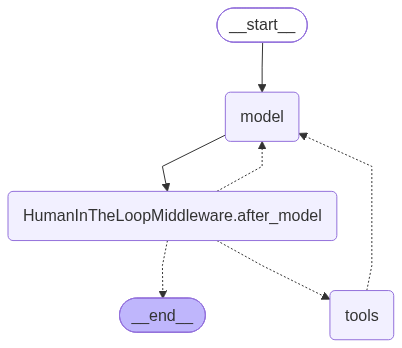

In [77]:
agent = create_agent(
    model='groq:openai/gpt-oss-120b',
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    'allowed_decisions': ['approve', 'edit','reject']
                },
                "read_email_tool": False
            }
        )
    ]
)
agent

In [78]:
config = {'configurable': {'thread_id': 'test-approve'}}
# step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to ashisheoran1@gmail.com with subject 'Hello' and body 'How are You?'")]},
    config=config
)

In [79]:
result

{'messages': [HumanMessage(content="Send email to ashisheoran1@gmail.com with subject 'Hello' and body 'How are You?'", additional_kwargs={}, response_metadata={}, id='270631d3-2830-49d1-8ccb-a273b5389ef8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email via function. Use send_email_tool.', 'tool_calls': [{'id': 'fc_07404d60-eb9e-44bf-972f-1b47154101fc', 'function': {'arguments': '{"body":"How are You?","recipient":"ashisheoran1@gmail.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 178, 'total_tokens': 241, 'completion_time': 0.137378588, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.008350963, 'prompt_tokens_details': None, 'queue_time': 0.285104166, 'total_time': 0.145729551}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_53dd116a39', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'log

In [80]:
from langgraph.types import Command
## step 1: Approve

if "__interrupt__" in result:
    print("Approving")

    result=agent.invoke(
        Command(
               resume={
                   "decisions":[
                       {"type":"approve"}
                   ]
               }
        ),
        config=config
    )
    print(f"✅Result: {result['messages'][-1].content}")

Approving
✅Result: The email has been sent successfully. Let me know if you need anything else!


#### Reject

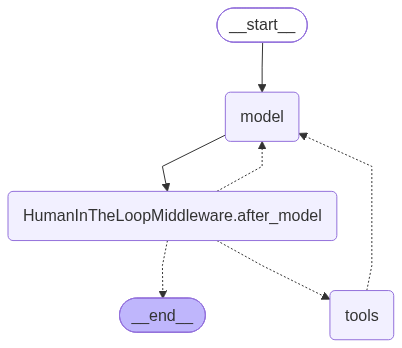

In [81]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient:str, subject:str, body:str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model='groq:openai/gpt-oss-120b',
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    'allowed_decisions': ['approve', 'edit','reject']
                },
                "read_email_tool": False
            }
        )
    ]
)
agent

In [82]:
config = {'configurable': {'thread_id': 'test-reject'}}
# step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to ashisheoran1@gmail.com with subject 'Hello' and body 'How are You?'")]},
    config=config
)

In [83]:
result

{'messages': [HumanMessage(content="Send email to ashisheoran1@gmail.com with subject 'Hello' and body 'How are You?'", additional_kwargs={}, response_metadata={}, id='291e50ed-166d-42e8-9423-d43c30550e2c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email. Use send_email_tool.', 'tool_calls': [{'id': 'fc_427485c1-5545-48e3-8ecc-ff46dbfb29b3', 'function': {'arguments': '{"body":"How are You?","recipient":"ashisheoran1@gmail.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 178, 'total_tokens': 241, 'completion_time': 0.132434846, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.009837041, 'prompt_tokens_details': None, 'queue_time': 0.381682267, 'total_time': 0.142271887}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logpro

In [84]:
from langgraph.types import Command
## step 1: Approve

if "__interrupt__" in result:
    print("⏸️Pause! Approving...")

    result=agent.invoke(
        Command(
               resume={
                   "decisions":[
                       {"type":"reject"}
                   ]
               }
        ),
        config=config
    )
    print(f"✅Result: {result['messages'][-1].content}")

⏸️Pause! Approving...
✅Result: Sure thing! I can send that email for you. Just to confirm, you’d like me to send an email to **ashisheoran1@gmail.com** with the subject **“Hello”** and the body **“How are You?”**. Let me know if everything looks good or if you’d like any changes.


#### Agent

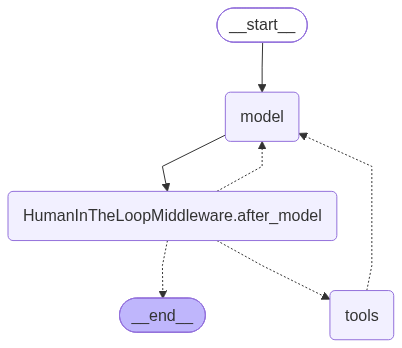

In [85]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient:str, subject:str, body:str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model='groq:openai/gpt-oss-120b',
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    'allowed_decisions': ['approve', 'edit','reject']
                },
                "read_email_tool": False
            }
        )
    ]
)
agent

In [86]:
config = {'configurable': {'thread_id': 'test-reject'}}
# step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@gmail.com with subject 'Test' and body 'Hello! How are You?'")]},
    config=config
)

In [87]:
result

{'messages': [HumanMessage(content="Send email to wrong@gmail.com with subject 'Test' and body 'Hello! How are You?'", additional_kwargs={}, response_metadata={}, id='bfee292f-5147-438a-b4cf-8230706f2448'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email using send_email_tool. Provide body, recipient, subject.', 'tool_calls': [{'id': 'fc_024b0ffb-4be2-451e-8a1a-9441bc864c3e', 'function': {'arguments': '{"body":"Hello! How are You?","recipient":"wrong@gmail.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 176, 'total_tokens': 242, 'completion_time': 0.137679282, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.010898326, 'prompt_tokens_details': None, 'queue_time': 0.376092747, 'total_time': 0.148577608}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason'

In [88]:
# step 2: Edit and approve
if "__interrupt" in result:
    print("⏸️ Paused! Editing...")
    result = agent.invoke(
        Command(
            resume={
                "decisions":[
                    {
                        "type":"edit",
                        "edited_action":{
                            "name":"send_email_tool", #Tool name
                            "args": {
                                "recipient": "correct@gmail.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )

In [89]:
result

{'messages': [HumanMessage(content="Send email to wrong@gmail.com with subject 'Test' and body 'Hello! How are You?'", additional_kwargs={}, response_metadata={}, id='bfee292f-5147-438a-b4cf-8230706f2448'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email using send_email_tool. Provide body, recipient, subject.', 'tool_calls': [{'id': 'fc_024b0ffb-4be2-451e-8a1a-9441bc864c3e', 'function': {'arguments': '{"body":"Hello! How are You?","recipient":"wrong@gmail.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 176, 'total_tokens': 242, 'completion_time': 0.137679282, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.010898326, 'prompt_tokens_details': None, 'queue_time': 0.376092747, 'total_time': 0.148577608}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason'